In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

In [ ]:
df = pd.read_csv('bengaluru_house_prices.csv')
print(df.shape)
df.head()


(13320, 9)


,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13320 entries, 0 to 13319
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   area_type     13320 non-null  object 
 1   availability  13320 non-null  object 
 2   location      13319 non-null  object 
 3   size          13304 non-null  object 
 4   society       7818 non-null   object 
 5   total_sqft    13320 non-null  object 
 6   bath          13247 non-null  float64
 7   balcony       12711 non-null  float64
 8   price         13320 non-null  float64
dtypes: float64(3), object(6)
memory usage: 936.7+ KB


In [ ]:
df.isnull().sum()

,0
area_type,0
availability,0
location,1
size,16
society,5502
total_sqft,0
bath,73
balcony,609
price,0


In [ ]:
df = df.drop('society', axis=1)
df = df.dropna(subset=['location', 'size', 'bath'])
df['balcony'] = df['balcony'].fillna(df['balcony'].median())

# Extract number of bedrooms (BHK) from size column, e.g. '2 BHK' -> 2
df['bhk'] = df['size'].apply(lambda x: int(x.split(' ')[0]))

df.isnull().sum()


,0
area_type,0
availability,0
location,0
size,0
total_sqft,0
bath,0
balcony,0
price,0
bhk,0


In [ ]:
def convert_sqft_to_num(x):
    x = str(x).strip()
    if '-' in x:
        parts = x.split('-')
        try:
            return (float(parts[0]) + float(parts[1])) / 2
        except:
            return None
    try:
        return float(x)
    except:
        return None  # handles weird units like 'Sq. Meter', 'Perch', etc.

df['total_sqft'] = df['total_sqft'].apply(convert_sqft_to_num)
df = df.dropna(subset=['total_sqft'])
print(df.shape)
df.head()

(13200, 9)


,area_type,availability,location,size,total_sqft,bath,balcony,price,bhk
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,1056.0,2.0,1.0,39.07,2
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,2600.0,5.0,3.0,120.00,4
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,1440.0,2.0,3.0,62.00,3
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,1521.0,3.0,1.0,95.00,3
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,1200.0,2.0,1.0,51.00,2


In [ ]:
df['location'] = df['location'].apply(lambda x: x.strip())

location_counts = df['location'].value_counts()
rare_locations = location_counts[location_counts <= 10].index

df['location'] = df['location'].apply(lambda x: 'other' if x in rare_locations else x)
print('Unique locations after grouping:', df['location'].nunique())


Unique locations after grouping: 241


In [ ]:
# Remove rows where sqft per bedroom is unrealistically small
df = df[~(df['total_sqft'] / df['bhk'] < 300)]
print(df.shape)

(12456, 9)


In [ ]:
# Remove rows with unrealistic number of bathrooms
df = df[df['bath'] < df['bhk'] + 2]
print(df.shape)

(12303, 9)


In [ ]:
# Create price_per_sqft to detect price outliers within each location
df['price_per_sqft'] = (df['price'] * 100000) / df['total_sqft']

def remove_pps_outliers(df):
    df_out = pd.DataFrame()
    for key, subdf in df.groupby('location'):
        m = np.mean(subdf.price_per_sqft)
        st = np.std(subdf.price_per_sqft)
        reduced_df = subdf[(subdf.price_per_sqft > (m - st)) & (subdf.price_per_sqft <= (m + st))]
        df_out = pd.concat([df_out, reduced_df], ignore_index=True)
    return df_out

df = remove_pps_outliers(df)
print(df.shape)


(10115, 10)


In [ ]:
# Drop helper columns we no longer need for modeling
df = df.drop(['size', 'price_per_sqft'], axis=1)
df.head()

,area_type,availability,location,total_sqft,bath,balcony,price,bhk
0,Super built-up Area,20-May,1st Block Jayanagar,2850.0,4.0,1.0,428.0,4
1,Super built-up Area,18-Jun,1st Block Jayanagar,1630.0,3.0,2.0,194.0,3
2,Super built-up Area,Ready To Move,1st Block Jayanagar,1875.0,2.0,3.0,235.0,3
3,Built-up Area,15-Dec,1st Block Jayanagar,1200.0,2.0,0.0,130.0,3
4,Super built-up Area,18-Jun,1st Block Jayanagar,1235.0,2.0,2.0,148.0,2


In [ ]:
df_encoded = pd.get_dummies(df, columns=['area_type', 'availability', 'location'], drop_first=True)
print(df_encoded.shape)
df_encoded.head()


(10115, 325)


,total_sqft,bath,balcony,price,bhk,area_type_Carpet Area,area_type_Plot Area,area_type_Super built-up Area,availability_14-Nov,availability_15-Aug,availability_15-Dec,availability_15-Jun,availability_15-Nov,availability_15-Oct,availability_16-Dec,availability_16-Jul,availability_16-Mar,availability_16-Nov,availability_16-Oct,availability_16-Sep,availability_17-Apr,availability_17-Aug,availability_17-Dec,availability_17-Jan,availability_17-Jul,availability_17-Jun,availability_17-Mar,availability_17-May,availability_17-Nov,availability_17-Oct,availability_17-Sep,availability_18-Apr,availability_18-Aug,availability_18-Dec,availability_18-Feb,availability_18-Jan,availability_18-Jul,availability_18-Jun,availability_18-Mar,availability_18-May,availability_18-Nov,availability_18-Oct,availability_18-Sep,availability_19-Apr,availability_19-Aug,availability_19-Dec,availability_19-Feb,availability_19-Jan,availability_19-Jul,availability_19-Jun,availability_19-Mar,availability_19-May,availability_19-Nov,availability_19-Oct,availability_19-Sep,availability_20-Apr,availability_20-Aug,availability_20-Dec,availability_20-Feb,availability_20-Jan,availability_20-Jul,availability_20-Jun,availability_20-Mar,availability_20-May,availability_20-Nov,availability_20-Oct,availability_20-Sep,availability_21-Aug,availability_21-Dec,availability_21-Feb,availability_21-Jan,availability_21-Jul,availability_21-Jun,availability_21-Mar,availability_21-May,availability_21-Nov,availability_21-Oct,availability_21-Sep,availability_22-Dec,availability_22-Jan,availability_22-Jun,availability_22-Mar,availability_22-May,availability_22-Nov,availability_Ready To Move,location_1st Phase JP Nagar,location_2nd Phase Judicial Layout,location_2nd Stage Nagarbhavi,location_5th Block Hbr Layout,location_5th Phase JP Nagar,location_6th Phase JP Nagar,location_7th Phase JP Nagar,location_8th Phase JP Nagar,location_9th Phase JP Nagar,location_AECS Layout,location_Abbigere,location_Akshaya Nagar,location_Ambalipura,location_Ambedkar Nagar,location_Amruthahalli,location_Anandapura,location_Ananth Nagar,location_Anekal,location_Anjanapura,location_Ardendale,location_Arekere,location_Attibele,location_BEML Layout,location_BTM 2nd Stage,location_BTM Layout,location_Babusapalaya,location_Badavala Nagar,location_Balagere,location_Banashankari,location_Banashankari Stage II,location_Banashankari Stage III,location_Banashankari Stage V,location_Banashankari Stage VI,location_Banaswadi,location_Banjara Layout,location_Bannerghatta,location_Bannerghatta Road,location_Basavangudi,location_Basaveshwara Nagar,location_Battarahalli,location_Begur,location_Begur Road,location_Bellandur,location_Benson Town,location_Bharathi Nagar,location_Bhoganhalli,location_Billekahalli,location_Binny Pete,location_Bisuvanahalli,location_Bommanahalli,location_Bommasandra,location_Bommasandra Industrial Area,location_Bommenahalli,location_Brookefield,location_Budigere,location_CV Raman Nagar,location_Chamrajpet,location_Chandapura,location_Channasandra,location_Chikka Tirupathi,location_Chikkabanavar,location_Chikkalasandra,location_Choodasandra,location_Cooke Town,location_Cox Town,location_Cunningham Road,location_Dasanapura,location_Dasarahalli,location_Devanahalli,location_Devarachikkanahalli,location_Dodda Nekkundi,location_Doddaballapur,location_Doddakallasandra,location_Doddathoguru,location_Domlur,location_Dommasandra,location_EPIP Zone,location_Electronic City,location_Electronic City Phase II,location_Electronics City Phase 1,location_Frazer Town,location_GM Palaya,location_Garudachar Palya,location_Giri Nagar,location_Gollarapalya Hosahalli,location_Gottigere,location_Green Glen Layout,location_Gubbalala,location_Gunjur,location_HAL 2nd Stage,location_HBR Layout,location_HRBR Layout,location_HSR Layout,location_Haralur Road,location_Harlur,location_Hebbal,location_Hebbal Kempapura,location_Hegde Nagar,location_Hennur,location_Hennur Road,location_Hoodi,location_Horamavu Agara,location_Horamavu Ban

In [ ]:
X = df_encoded.drop('price', axis=1)
y = df_encoded['price']

# Make sure everything is numeric (bool -> int)
X = X.astype(float)

print('X shape:', X.shape)
print('y shape:', y.shape)


X shape: (10115, 324)
y shape: (10115,)


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print('Train shape:', X_train_scaled.shape)
print('Test shape:', X_test_scaled.shape)

Train shape: (8092, 324)
Test shape: (2023, 324)


In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping

tf.random.set_seed(42)

def build_model(input_dim, n_layers=3, n_neurons=128, dropout_rate=0.2, learning_rate=0.001):
    model = keras.Sequential()
    model.add(layers.Input(shape=(input_dim,)))

    neurons = n_neurons
    for i in range(n_layers):
        model.add(layers.Dense(neurons, activation='relu'))
        model.add(layers.Dropout(dropout_rate))
        neurons = max(neurons // 2, 16)  # shrink layer size progressively

    model.add(layers.Dense(1, activation='linear'))  # regression output

    optimizer = keras.optimizers.Adam(learning_rate=learning_rate)
    model.compile(optimizer=optimizer, loss='mse', metrics=['mae'])
    return model


In [ ]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import itertools

param_grid = {
    'n_layers': [2, 3],
    'n_neurons': [64, 128],
    'dropout_rate': [0.1, 0.2],
    'learning_rate': [0.001, 0.0005]
}

keys = list(param_grid.keys())
combinations = list(itertools.product(*param_grid.values()))
print(f'Total combinations to try: {len(combinations)}')


Total combinations to try: 16


In [ ]:
results = []

early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)

for combo in combinations:
    params = dict(zip(keys, combo))

    model = build_model(
        input_dim=X_train_scaled.shape[1],
        n_layers=params['n_layers'],
        n_neurons=params['n_neurons'],
        dropout_rate=params['dropout_rate'],
        learning_rate=params['learning_rate']
    )

    history = model.fit(
        X_train_scaled, y_train,
        validation_split=0.2,
        epochs=200,
        batch_size=32,
        callbacks=[early_stop],
        verbose=0
    )

    y_pred = model.predict(X_test_scaled, verbose=0).flatten()
    r2 = r2_score(y_test, y_pred)

    results.append({**params, 'r2_score': r2, 'epochs_trained': len(history.history["loss"])})
    print(f"Params: {params} -> R2: {r2:.4f}")

Params: {'n_layers': 2, 'n_neurons': 64, 'dropout_rate': 0.1, 'learning_rate': 0.001} -> R2: 0.7493
Params: {'n_layers': 2, 'n_neurons': 64, 'dropout_rate': 0.1, 'learning_rate': 0.0005} -> R2: -0.6983
Params: {'n_layers': 2, 'n_neurons': 64, 'dropout_rate': 0.2, 'learning_rate': 0.001} -> R2: 0.3373
Params: {'n_layers': 2, 'n_neurons': 64, 'dropout_rate': 0.2, 'learning_rate': 0.0005} -> R2: -0.0961
Params: {'n_layers': 2, 'n_neurons': 128, 'dropout_rate': 0.1, 'learning_rate': 0.001} -> R2: 0.4867
Params: {'n_layers': 2, 'n_neurons': 128, 'dropout_rate': 0.1, 'learning_rate': 0.0005} -> R2: 0.3079
Params: {'n_layers': 2, 'n_neurons': 128, 'dropout_rate': 0.2, 'learning_rate': 0.001} -> R2: 0.4551
Params: {'n_layers': 2, 'n_neurons': 128, 'dropout_rate': 0.2, 'learning_rate': 0.0005} -> R2: 0.2809
Params: {'n_layers': 3, 'n_neurons': 64, 'dropout_rate': 0.1, 'learning_rate': 0.001} -> R2: 0.4534
Params: {'n_layers': 3, 'n_neurons': 64, 'dropout_rate': 0.1, 'learning_rate': 0.0005} -> 

In [ ]:
results_df = pd.DataFrame(results).sort_values('r2_score', ascending=False).reset_index(drop=True)
results_df


,n_layers,n_neurons,dropout_rate,learning_rate,r2_score,epochs_trained
0,2,64,0.1,0.0010,0.749298,71
1,3,128,0.2,0.0010,0.513051,15
2,3,128,0.1,0.0010,0.497432,15
3,2,128,0.1,0.0010,0.486723,15
4,2,128,0.2,0.0010,0.455094,15
5,3,64,0.1,0.0010,0.453425,15
6,3,64,0.2,0.0010,0.418677,15
7,3,128,0.1,0.0005,0.389479,15
8,3,128,0.2,0.0005,0.381007,15
9,2,64,0.2,0.0010,0.337310,15


In [ ]:
best_params = results_df.iloc[0].to_dict()
print('Best Parameters:')
print(best_params)


Best Parameters:
{'n_layers': 2.0, 'n_neurons': 64.0, 'dropout_rate': 0.1, 'learning_rate': 0.001, 'r2_score': 0.7492983852081874, 'epochs_trained': 71.0}


In [ ]:
final_model = build_model(
    input_dim=X_train_scaled.shape[1],
    n_layers=int(best_params['n_layers']),
    n_neurons=int(best_params['n_neurons']),
    dropout_rate=best_params['dropout_rate'],
    learning_rate=best_params['learning_rate']
)

final_history = final_model.fit(
    X_train_scaled, y_train,
    validation_split=0.2,
    epochs=300,
    batch_size=32,
    callbacks=[EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)],
    verbose=1
)

Epoch 1/300
203/203 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 8305.1758 - mae: 54.8604 - val_loss: 5248.1475 - val_mae: 30.9806
Epoch 2/300
203/203 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 3271.0562 - mae: 28.9334 - val_loss: 4176.0532 - val_mae: 25.7729
Epoch 3/300
203/203 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 2592.0032 - mae: 25.9911 - val_loss: 3697.5212 - val_mae: 24.2461
Epoch 4/300
203/203 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 2124.5398 - mae: 24.1784 - val_loss: 3370.1182 - val_mae: 22.9117
Epoch 5/300
203/203 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1813.2913 - mae: 23.1548 - val_loss: 3114.6489 - val_mae: 22.0752
Epoch 6/300
203/203 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1591.6749 - mae: 21.7913 - val_loss: 2962.8975 - val_mae: 21.5798
Epoch 7/300
203/203 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1445.1570 - mae: 21.2834 - val_loss: 2854.1733 - val_mae: 21.1730
Epoch 8/300
203/203 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1322.7762 - mae: 20.5197 - val_loss: 2767.0386 - v

In [ ]:
y_pred_final = final_model.predict(X_test_scaled, verbose=0).flatten()

final_r2 = r2_score(y_test, y_pred_final)
final_mae = mean_absolute_error(y_test, y_pred_final)
final_rmse = np.sqrt(mean_squared_error(y_test, y_pred_final))

print(f'Final R2 Score: {final_r2:.4f}')
print(f'Final MAE: {final_mae:.4f}')
print(f'Final RMSE: {final_rmse:.4f}')


Final R2 Score: 0.7740
Final MAE: 17.9082
Final RMSE: 35.9587


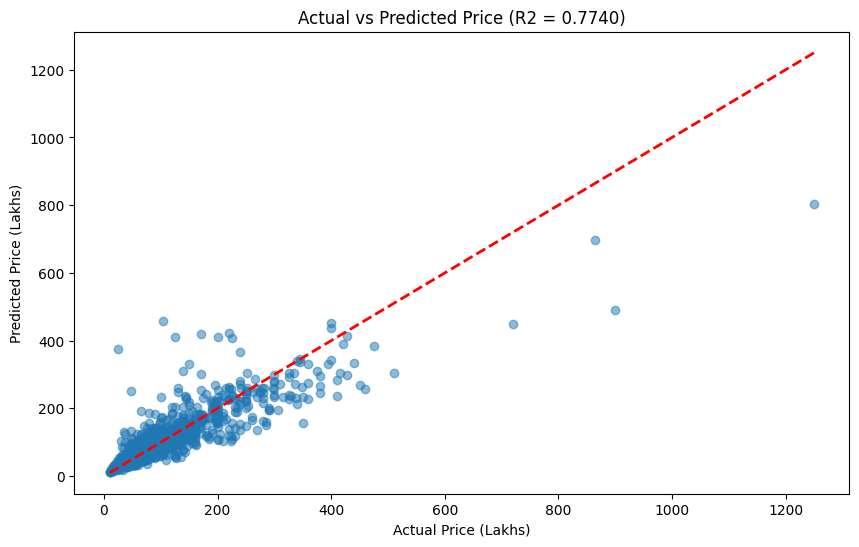

In [ ]:
plt.figure(figsize=(10,6))
plt.scatter(y_test, y_pred_final, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Price (Lakhs)')
plt.ylabel('Predicted Price (Lakhs)')
plt.title(f'Actual vs Predicted Price (R2 = {final_r2:.4f})')
plt.show()


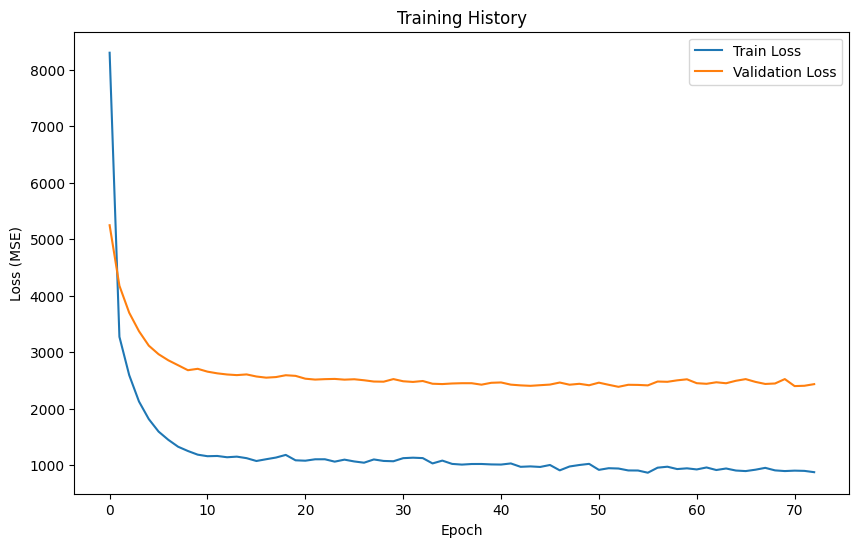

In [ ]:
plt.figure(figsize=(10,6))
plt.plot(final_history.history['loss'], label='Train Loss')
plt.plot(final_history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.title('Training History')
plt.legend()
plt.show()
